In [28]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras 
from keras.layers import Dense 
from keras.models import Sequential
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df = pd.read_csv("ushape.csv")

In [30]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


In [31]:
x = df.iloc[: , 0:2]
y = df.iloc[: , -1]

In [32]:
model = Sequential()

model.add(Dense(10 , activation= 'tanh' , input_dim = 2 , kernel_initializer= "glorot_uniform"))
model.add(Dense(10 , activation= 'tanh' , kernel_initializer= "glorot_uniform"))
model.add(Dense(10 , activation= 'tanh' , kernel_initializer= "glorot_uniform"))
model.add(Dense(10 , activation= 'tanh' , kernel_initializer= "glorot_uniform"))
model.add(Dense(1, activation= 'sigmoid' , kernel_initializer= "glorot_uniform"))

model.summary()

c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
inital_weights = model.get_weights()

In [34]:
inital_weights[0]

array([[ 0.12408352, -0.02009308,  0.05799776, -0.4573464 ,  0.58275265,
         0.61457795,  0.47694665,  0.10090852, -0.08711869,  0.59002   ],
       [-0.09554368,  0.15679097, -0.0155102 , -0.36911047, -0.18764132,
         0.6299458 ,  0.09875274, -0.32690158, -0.01258975,  0.0308395 ]],
      dtype=float32)

In [35]:
model.compile(loss= 'binary_crossentropy' , optimizer= 'adam' , metrics= ['accuracy'])
history = model.fit(x , y , validation_split= 0.2 , epochs= 100 , verbose= False )

In [36]:
model.get_weights()[0]

array([[ 0.22213534, -0.10518871,  0.19391492, -0.56438214,  0.45506743,
         0.57036906,  0.3303061 ,  0.21211371, -0.05639347,  0.47534767],
       [-0.2053296 ,  0.2967194 , -0.16667019, -0.30551085, -0.14910631,
         0.7263901 , -0.0337323 , -0.45562196,  0.10537351, -0.13266748]],
      dtype=float32)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 778us/step


<Axes: >

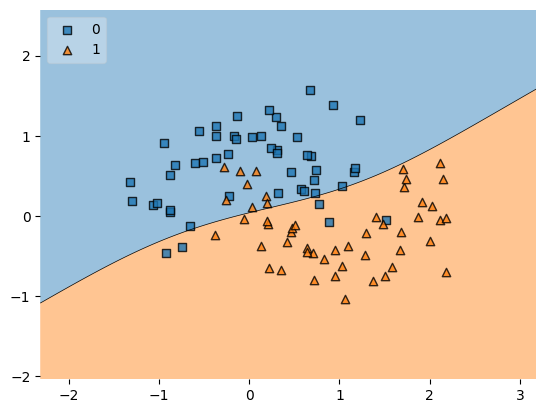

In [37]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.values , y.values.astype('int') , clf= model , legend= 2)